# Lab 02: Linear Regression

Regression is a problem where learn the relationship between input variable $\mathbf{x}$ and real-valued output variable $y$ via a dataset $\mathcal{D} = \{ (\mathbf{x}_n, y_n) \}_{n=1}^N$.

Linear regression is where we assume a linear relationship between those variables:

$$
  y \approx f(\mathbf{x}; \boldsymbol{\theta}) = \mathbf{w}^\top \mathbf{x} + b ,
$$

where $\mathbf{w}$ is the weight vector and $b$ is the bias term.
Altogether, we can represent the parameters as a single vector $\boldsymbol{\theta} = [\mathbf{w}, b]^\top$.

The function $f(\mathbf{x}; \boldsymbol{\theta})$ is called the **model** and $\boldsymbol{\theta}$ are the **parameters** of the model.
The parameters $\boldsymbol{\theta}$ has the same dimension as the input variable $\mathbf{x}$.
The goal of linear regression is to learn the parameters $\boldsymbol{\theta}$ that best fit the data.

## Data Loading and Visualization

We will use the GDP dataset from Our World in Data (OWID), which contains the GDP of different countries over time.

In [1]:
import pandas as pd

df = pd.read_csv("owid-gdp.csv")
df

,Entity,Code,Year,GDP
0,Afghanistan,AFG,2000,6206547590
1,Afghanistan,AFG,2001,5621147630
2,Afghanistan,AFG,2002,7228795918
3,Afghanistan,AFG,2003,7867263256
4,Afghanistan,AFG,2004,7978515641
...,...,...,...,...
12159,Zimbabwe,ZWE,2020,19110793941
12160,Zimbabwe,ZWE,2021,20729099176
12161,Zimbabwe,ZWE,2022,22001713149
12162,Zimbabwe,ZWE,2023,23178995952


In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12164 entries, 0 to 12163
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Entity  12164 non-null  str  
 1   Code    12164 non-null  str  
 2   Year    12164 non-null  int64
 3   GDP     12164 non-null  int64
dtypes: int64(2), str(2)
memory usage: 380.3 KB
None


In [3]:
df["Entity"].unique()

<StringArray>
[                  'Afghanistan',                       'Albania',
                       'Algeria',                'American Samoa',
                       'Andorra',                        'Angola',
           'Antigua and Barbuda',                     'Argentina',
                       'Armenia',                         'Aruba',
 ...
 'Upper-middle-income countries',                       'Uruguay',
                    'Uzbekistan',                       'Vanuatu',
                     'Venezuela',                       'Vietnam',
                         'World',                         'Yemen',
                        'Zambia',                      'Zimbabwe']
Length: 226, dtype: str

We will focus on Canada for this lab.
Let's filter the dataset to only include data for Canada.

In [4]:
df_canada = df[df["Entity"] == "Canada"]

df_canada

,Entity,Code,Year,GDP
1777,Canada,CAN,1960,276385630513
1778,Canada,CAN,1961,285128514178
1779,Canada,CAN,1962,306307396491
1780,Canada,CAN,1963,322533846696
1781,Canada,CAN,1964,344001699477
...,...,...,...,...
1837,Canada,CAN,2020,1611126165625
1838,Canada,CAN,2021,1706996679677
1839,Canada,CAN,2022,1778503389905
1840,Canada,CAN,2023,1805692180594


Now let's visualize the GDP of Canada over time.

Text(0, 0.5, 'GDP (USD)')

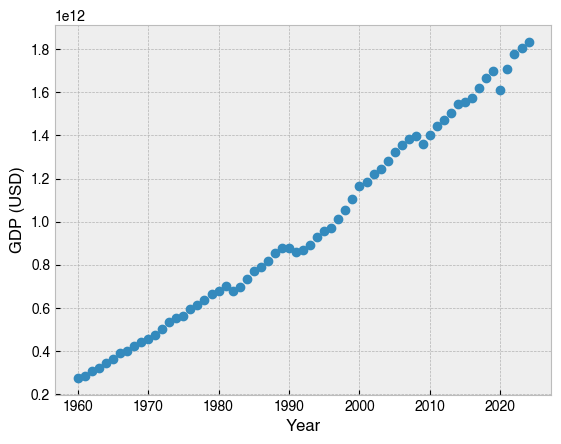

In [5]:
import matplotlib.pyplot as plt

plt.style.use("bmh")
plt.rcParams["font.family"] = ["Helvetica"]

plt.plot(df_canada["Year"], df_canada["GDP"], marker="o", linestyle="none")
plt.xlabel("Year")
plt.ylabel("GDP (USD)")

Note that the y-axis is very large (GDP is in trillions of USD), so let's divide the GDP by 1 trillion to make it easier to digest.

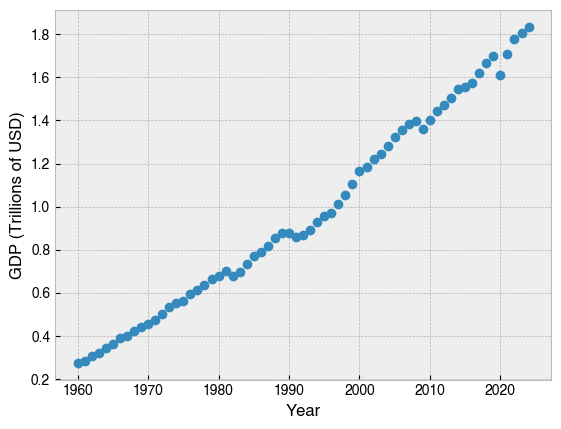

In [6]:
df_canada["GDP"] = df_canada["GDP"] / 1e12

def plot_gdp(years: np.ndarray, gdp_in_trillions: np.ndarray) -> None:
    """Plot the GDP.

    Args:
        years: Array of years, shape (N,).
        gdp: Array of GDP values, shape (N,).
    """
    plt.plot(years, gdp_in_trillions, marker="o", linestyle="none")
    plt.xlabel("Year")
    plt.ylabel("GDP (Trillions of USD)")


plot_gdp(df_canada["Year"].values, df_canada["GDP"].values)

Suppose we have missing GDP data between 1980 and 1990, we can simulate that by removing those rows from the dataset.

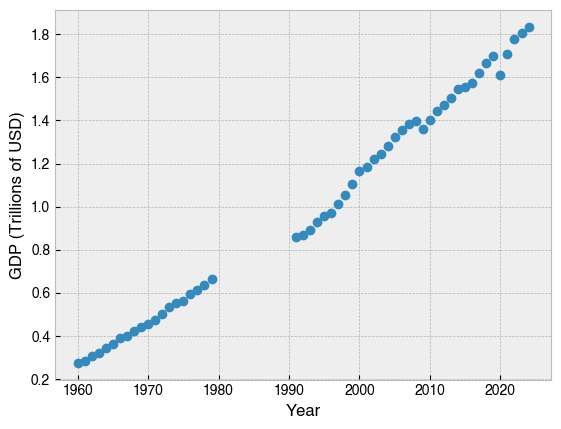

In [7]:
df_canada_missing = df_canada.query("Year < 1980 or Year > 1990")

plot_gdp(df_canada_missing["Year"].values, df_canada_missing["GDP"].values)

This will be our training dataset.
We will use the learned model to predict the GDP of Canada between 1980 and 1990, and compare it with the actual GDP.

## Training a Linear Regression Model

First we define our parameters $\boldsymbol{\theta} = [\mathbf{w}, b]$ and the model $f(\mathbf{x}; \boldsymbol{\theta})$.
Recall, we can represent this as simple vector-vector multiplication by adding a constant term to the input variable: $\hat{\mathbf{x}} = [\mathbf{x}; 1]$.

In [ ]:
import numpy as np

def preprocess(x: np.ndarray) -> np.ndarray:
    """Preprocess the input variable by adding a constant term.

    Args:
        x: Input variable, shape (N,).
    Output:
        Preprocessed input variable, shape (N, 2).
    """
    ones = np.ones_like(x)  # shape (N,)
    return np.stack([x, ones], axis=1)  # shape (N, 2)

Then, we have $f(\hat{\mathbf{x}}; \boldsymbol{\theta}) = \boldsymbol{\theta}^\top \hat{\mathbf{x}}$.

In [ ]:
def predict(x: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """Predict the output given input x and parameters theta.

    Args:
        x: Input variable, shape (N,).
        theta: Parameters, shape (2,).
    Output:
        Predicted output, shape (N,).
    """
    x_hat = preprocess(x)  # shape (N, 2)
    return x_hat @ theta  # shape (N,)

Recall the normal equation for linear regression:

$$
\boldsymbol{\theta} = (\hat{\mathbf{X}}^\top \hat{\mathbf{X}})^{-1} \hat{\mathbf{X}}^\top \mathbf{y}
$$

In [10]:
X = df_canada_missing["Year"].values
y = df_canada_missing["GDP"].values

X_hat = preprocess(X)  # shape (N, 2)

theta = np.linalg.inv(X_hat.T @ X_hat) @ X_hat.T @ y

Let's visualize the learned model.

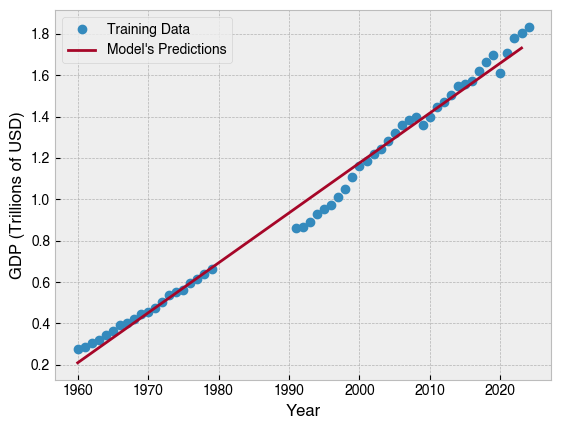

In [11]:
plt.plot(
  df_canada_missing["Year"],
  df_canada_missing["GDP"],
  marker="o",
  linestyle="none",
  label="Training Data"
)

plt.plot(
  np.arange(1960, 2024),
  predict(np.arange(1960, 2024), theta),
  label="Model's Predictions"
)

plt.xlabel("Year")
plt.ylabel("GDP (Trillions of USD)")

plt.legend()

We can also quantify the performance of our model by calculating the mean squared error (MSE) on the training data.

In [12]:
def MSE(y_true: np.ndarray, y_pred: np.ndarray) -> np.float64:
    """Calculate the mean squared error between true and predicted values.

    Args:
        y_true: True values, shape (N,).
        y_pred: Predicted values, shape (N,).
    Output:
        Mean squared error.
    """
    return np.mean((y_true - y_pred) ** 2)


print("Training MSE:", MSE(y, predict(X, theta)))

Training MSE: 0.002532494604594929


Since the MSE is squared, it is in the unit of GDP squared, which is not very interpretable.
We can instead show the root mean squared error (RMSE).

In [13]:
rmse = np.sqrt(MSE(y, predict(X, theta)))
print(f"Training RMSE: {rmse:,.2f}T USD")

Training RMSE: 0.05T USD


## Prediction and Evaluation

Let's test our model by predicting the GDP of Canada between 1980 and 1990.

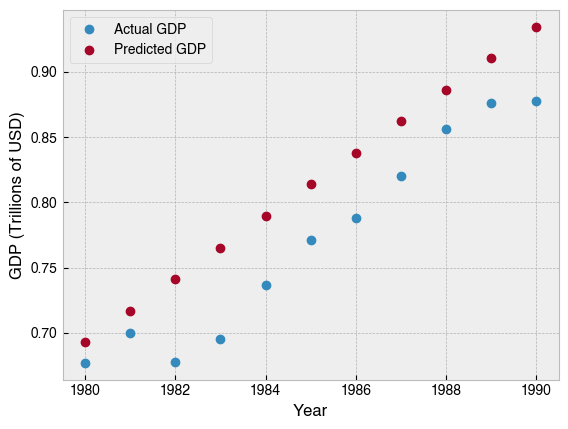

In [14]:
X_test = np.arange(1980, 1991)
y_test = df_canada.query("1980 <= Year <= 1990")["GDP"].values

y_pred = predict(X_test, theta)

plt.plot(X_test, y_test, marker="o", linestyle="none", label="Actual GDP")
plt.plot(X_test, y_pred, marker="o", linestyle="none", label="Predicted GDP")

plt.xlabel("Year")
plt.ylabel("GDP (Trillions of USD)")

plt.legend()

The test RMSE can also be calculated to evaluate the performance of our model on the test data.

In [15]:
print(f"Test RMSE: {np.sqrt(MSE(y_test, y_pred)):,.2f}T USD")

Test RMSE: 0.05T USD


## Basis Function

Notice that the prediction is constrained to just a straight line, which the data is not.
To add non-linearity, we can use a basis function $\phi(x)$ that encodes non-linear transformation of $x$. For example:

$$
  \phi(x) = [1, x, x^2]^\top \in \mathbb{R}^3 .
$$

The parameter $\boldsymbol{\theta}$ is now also in $\mathbb{R}^3$.

In [16]:
def phi(x: np.ndarray) -> np.ndarray:
    ones = np.ones_like(x)  # shape (N,)
    return np.stack([ones, x, x**2], axis=1)  # shape (N, 3)


def predict_with_phi(x: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """Predict the output given input x and parameters theta, with basis function.

    Args:
        x: Input variable, shape (N,).
        theta: Parameters, shape (5,).
    Output:
        Predicted output, shape (N,).
    """
    return phi(x) @ theta

Let's learn the parameter $\boldsymbol{\theta}$ as before, but replace $\mathbf{X}$ with $\boldsymbol{\Phi} = [\phi(x_1), ..., \phi(x_N)]^\top \in \mathbb{R}^{N \times 3}$.

In [17]:
X = df_canada_missing["Year"].values
y = df_canada_missing["GDP"].values

Phi = phi(X)  # shape (N, 3)

theta_phi = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y

print(theta_phi)

[ 4.45378043e+02 -4.70519519e-01  1.24198646e-04]


Now let's check the resulting model.

Text(0.5, 1.0, 'With Phi')

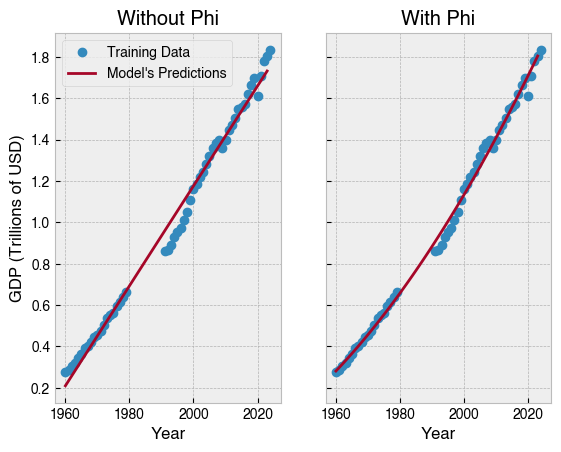

In [18]:
fig, axes = plt.subplots(1, 2, sharey=True)

years = np.arange(1960, 2024)
y_pred = predict(years, theta)
y_pred_phi = predict_with_phi(years, theta_phi)

for i, gdp in enumerate([y_pred, y_pred_phi]):
    axes[i].plot(
      df_canada_missing["Year"],
      df_canada_missing["GDP"],
      marker="o",
      linestyle="none",
      label="Training Data"
    )
    
    axes[i].plot(
      years,
      gdp,
      label="Model's Predictions"
    )

    axes[i].set_xlabel("Year")

axes[0].set_title("Without Phi")
axes[0].set_ylabel("GDP (Trillions of USD)")
axes[0].legend()

axes[1].set_title("With Phi")

In [19]:
y_pred = predict_with_phi(X_test, theta_phi)
print(f"Test RMSE: {np.sqrt(MSE(y_test, y_pred)):,.2f}T USD")

Test RMSE: 0.02T USD
